In [1]:
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv",usecols=['Age','Fare','Survived'])

In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [7]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [8]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [10]:
dtc = DecisionTreeClassifier()

In [11]:
dtc.fit(X_train,Y_train)
Y_pred = dtc.predict(X_test)

In [12]:
accuracy_score(Y_test,Y_pred)

0.6293706293706294

In [13]:
r2_score(Y_test,Y_pred)

-0.5556239737274222

In [17]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=10,scoring='accuracy'))

np.float64(0.6260954616588419)

In [29]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [30]:
trf = ColumnTransformer([('first',kbin_age,[0]),
                        ('second',kbin_fare,[1])])

In [31]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [32]:
trf.named_transformers_['first'].n_bins_

array([10])

In [36]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [37]:
op = pd.DataFrame({
    'Age':X_train['Age'],
    'Age_Trf':X_train_trf[:,0],
    'Fare':X_train['Fare'],
    'Fare_Trf':X_train_trf[:,1]
})

In [38]:
op['Age_Labels'] = pd.cut(x = X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
op['Fare_Labels'] = pd.cut(x = X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [39]:
op.sample(5)

,Age,Age_Trf,Fare,Fare_Trf,Age_Labels,Fare_Labels
695,52.0,9.0,13.5000,4.0,"(50.0, 80.0]","(13.0, 15.75]"
617,26.0,4.0,16.1000,5.0,"(25.0, 28.5]","(15.75, 26.0]"
257,30.0,5.0,86.5000,9.0,"(28.5, 32.0]","(82.171, 512.329]"
408,21.0,2.0,7.7750,1.0,"(19.0, 22.0]","(7.75, 7.896]"
569,32.0,6.0,7.8542,1.0,"(28.5, 32.0]","(7.75, 7.896]"


In [41]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_trf,Y_train)
Y_pred2 = dtc.predict(X_test_trf)

In [42]:
accuracy_score(Y_test,Y_pred2)

0.6223776223776224

In [44]:
r2_score(Y_test,Y_pred2)

-0.5849753694581283

In [45]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=10,scoring='accuracy'))

np.float64(0.6316705790297339)

In [58]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([('first',kbin_age,[0]),
                            ('second',kbin_fare,[1])])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("After")

    plt.show()

0.6260954616588419


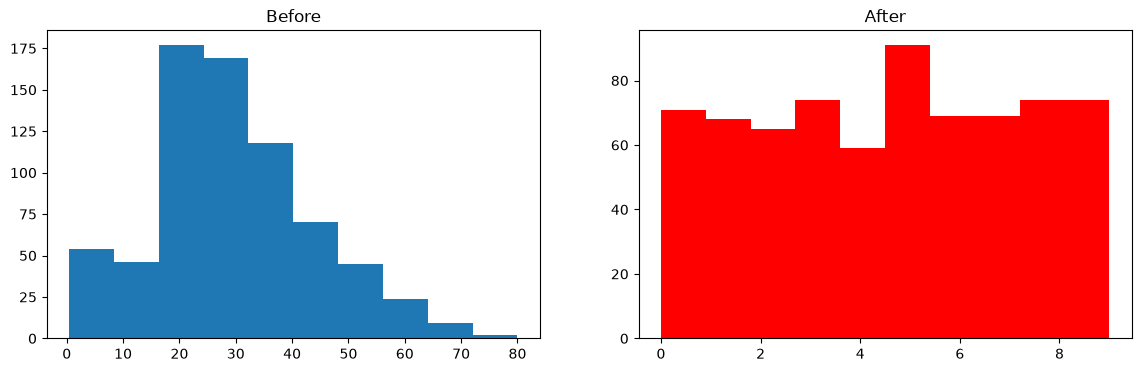

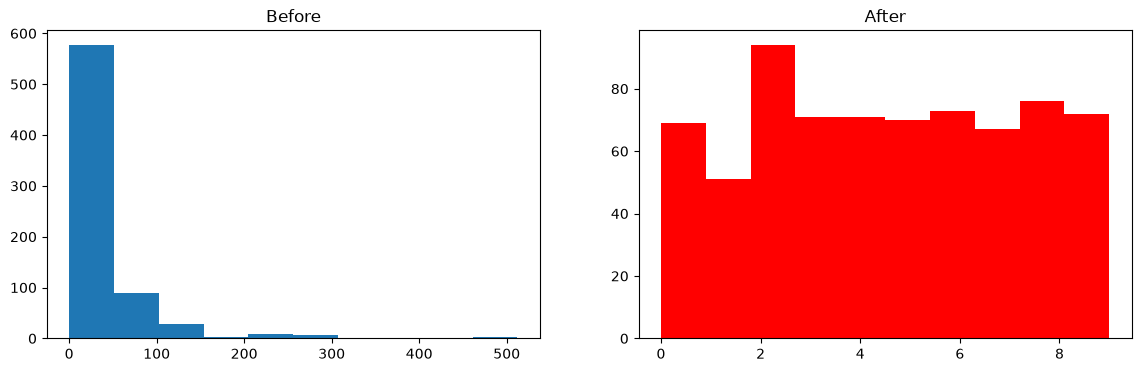

In [59]:
discretize(10,'quantile')

0.6289123630672927


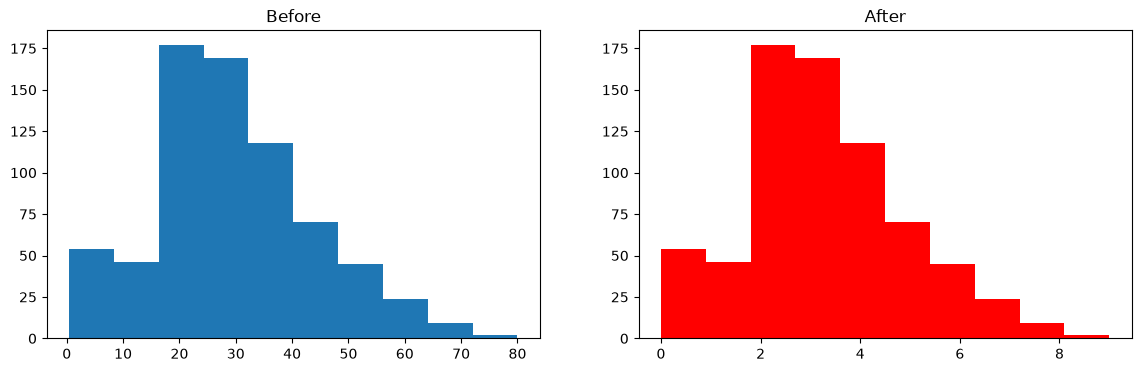

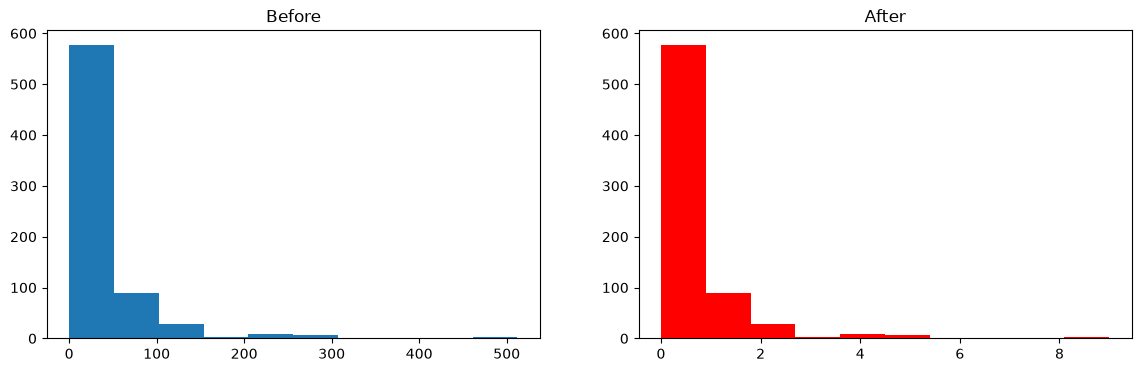

In [60]:
discretize(10,'uniform')

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6358763693270735


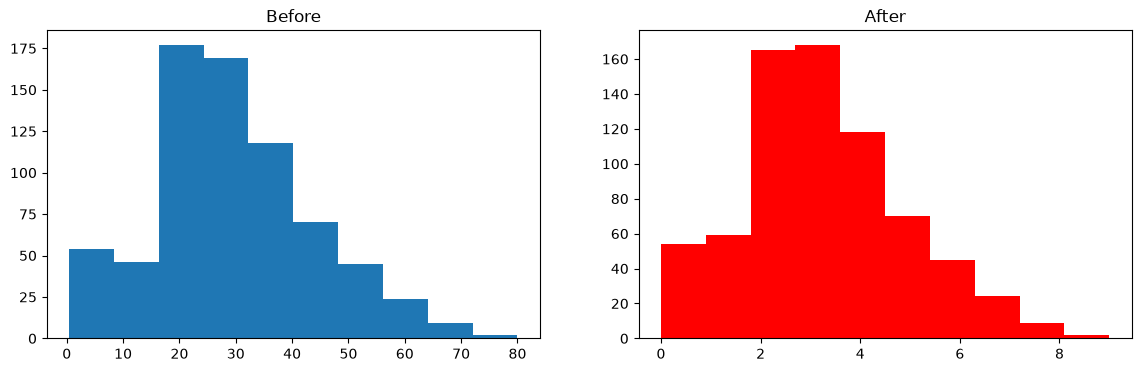

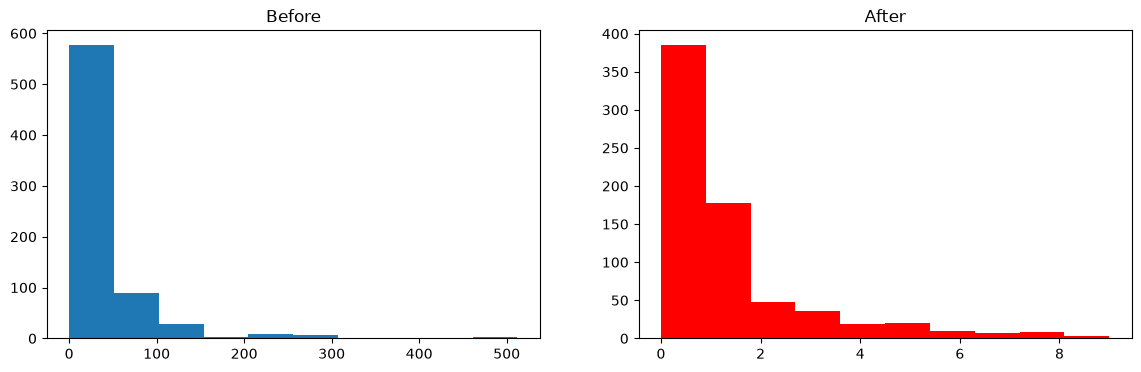

In [61]:
discretize(10,'kmeans')


In [63]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv",usecols=['Age','Fare','SibSp','Parch','Survived'])

In [64]:
df.dropna(inplace=True)

In [65]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [66]:
df['Family'] = df['SibSp'] + df['Parch']

In [67]:
df.head()

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [68]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [69]:
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [70]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [71]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [72]:
X_train.head()

,Age,Fare,Family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [73]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train,Y_train)
Y_pred = dtc.predict(X_test)
accuracy_score(Y_test,Y_pred)

0.6223776223776224

In [74]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=10,scoring='accuracy'))

np.float64(0.6471048513302035)

In [75]:
from sklearn.preprocessing import Binarizer

In [80]:
trf = ColumnTransformer([('bin',Binarizer(copy=False),['Family'])],remainder='passthrough')

In [89]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [90]:
pd.DataFrame(X_train_trf,columns=['Family','Age','Fare'])

,Family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [91]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_trf,Y_train)
Y_pred2 = dtc.predict(X_test_trf)
accuracy_score(Y_test,Y_pred2)

0.6153846153846154

In [92]:
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,Y,cv=10,scoring='accuracy'))

np.float64(0.6807316118935838)